In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

from ejercicio1_utils import search_pi, search_zeta_wn

## Parte A)

### a)

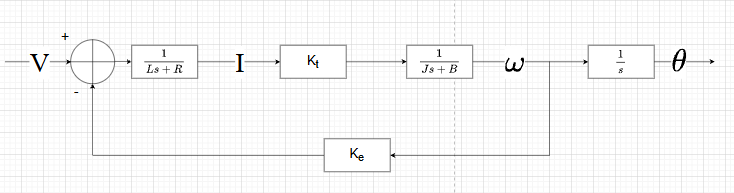

$$I(s)(Ls+R)+K_{e}s\theta(s)=V(s)$$


$$Js²\theta(s)+ Bs\theta(s)=K_tI(s)$$

$$\frac{Js²\theta(s)+ Bs\theta(s)}{K_t}=I(s)$$


$$\frac{Js²\theta(s)+ Bs\theta(s)}{K_t}(Ls+R)+K_{e}s\theta(s)=V(s)$$

$$\theta(s)(\frac{Js²+ Bs}{K_t}(Ls+R)+K_{e}s)=V(s)$$

$$G(s)=\frac{\theta(s)}{V(s)}=\frac{K_t}{s[s²LJ +s(LB + RJ) + K_tK_e + RB ]}$$

$$G(s)=\frac{\theta(s)}{V(s)}=\frac{0.25}{s[s²0.15*0.02 +s(0.15*0.25 + 0.7*0.02) + 0.25*0.1 + 0.7*0.25 ]}$$

$$G(s)=\frac{\theta(s)}{V(s)}=\frac{0.25}{s[0.003s² + 0.0515s + 0.2]}$$




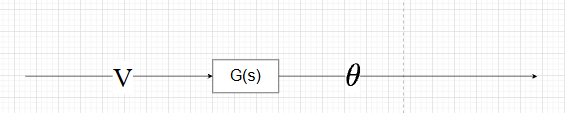

variables de estado

$$
X_1 = i,\quad X_2 = \omega,\quad X_3 = \theta
$$

$$
L\dot{X}_1 + R X_1 + K_e X_2 = V
$$

$$
J\dot{X}_2 + B X_2 = K_t X_1
$$

$$
\begin{bmatrix}
\dot{X}_1 \\
\dot{X}_2 \\
\dot{X}_3
\end{bmatrix}
=
\begin{bmatrix}
-\frac{R}{L} & -\frac{K_e}{L} & 0 \\
\frac{K_t}{J} & -\frac{B}{J} & 0 \\
0 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
X_1 \\
X_2 \\
X_3
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{L} \\
0 \\
0
\end{bmatrix}
V
$$


$$
\begin{bmatrix}
\dot{X}_1 \\
\dot{X}_2 \\
\dot{X}_3
\end{bmatrix}
=
\begin{bmatrix}
-\frac{0.7}{0.15} & -\frac{0.1}{0.15} & 0 \\
12.5 & -12.5 & 0 \\
0 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
X_1 \\
X_2 \\
X_3
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{0.15} \\
0 \\
0
\end{bmatrix}
V
$$


$$
Y
=
\begin{bmatrix}
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
X_1 \\
X_2 \\
X_3
\end{bmatrix}
$$



### b)

In [ ]:
a = 0.25
b = 0.003
c = 0.0515
d = 0.2

num = [a]
den = [b, c, d, 0]

G = ctrl.TransferFunction(num, den)

gm, pm, wg, wp = ctrl.margin(G)

print(f"Margen de ganancia: {20 * math.log10(gm):4.2f} dB")
print(f"Margen de fase: {pm:4.2f} grados")

Margen de ganancia: 22.76 dB
Margen de fase: 72.22 grados


Dado que "valores adecuados (MG > 6 dB y MF ~30°−60°) aseguran que el sistema permanecerá estable frente a variaciones en los componentes o dinámica no modelada", con nuestros valores no deberiamos introducir un compensador.

### c)

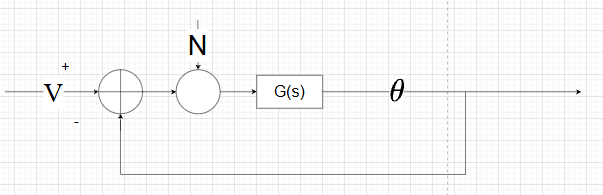

$$E(s)=V(s)-\theta(s)$$

$$\theta = (E(s) + N(s))G(s)$$

$$\theta = (V(s)-\theta(s) + N(s))G(s)$$

$$(1 + G(s))\theta = G(s)V(s) + G(s)N(s)$$

$$\theta = \frac{G(s)}{1 + G(s)}V(s) + \frac{G(s)}{1 + G(s)}N(s)$$

$$\theta(s)=\frac{\theta(s)}{V(s)}V(s) + \frac{\theta(s)}{N(s)}N(s)$$

con $$G(s)=\frac{0.25}{s[0.003s² + 0.0515s + 0.2]}$$

$$\frac{G(s)}{1 + G(s)} = \frac{ \frac{0.25}{s[0.003s² + 0.0515s + 0.2]}}{ 1+ \frac{0.25}{s[0.003s² + 0.0515s + 0.2]}} = \frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s + 0.25}$$

$$\theta(s)=\frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s + 0.25}V(s) + \frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s + 0.25}N(s)$$


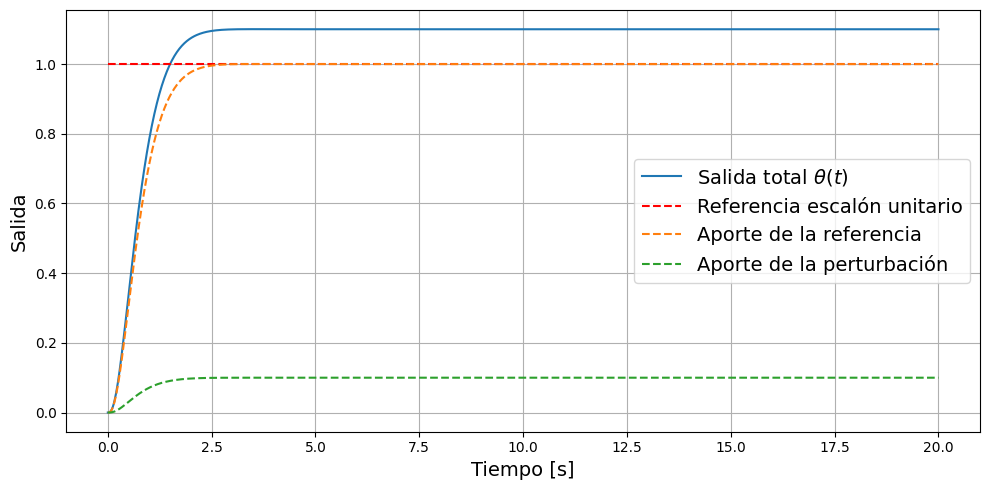

In [22]:
den = [0.003, 0.0515, 0.2, 0.25]

Tv = ctrl.TransferFunction([0.25], den)
Tn = ctrl.TransferFunction([0.25], den)

t = np.linspace(0, 20, 1000)

t1, y_ref = ctrl.step_response(Tv, T=t)
t2, y_pert = ctrl.step_response(0.1 * Tn, T=t)

y_total = y_ref + y_pert

r = np.ones_like(t)

plt.figure(figsize=(10, 5))
plt.plot(t, y_total, label="Salida total $\\theta(t)$")
plt.plot(t, r, "r--", label="Referencia escalón unitario")

plt.plot(t, y_ref, "--", label="Aporte de la referencia")
plt.plot(t, y_pert, "--", label="Aporte de la perturbación")

plt.xlabel("Tiempo [s]", fontsize=14)
plt.ylabel("Salida", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### d)

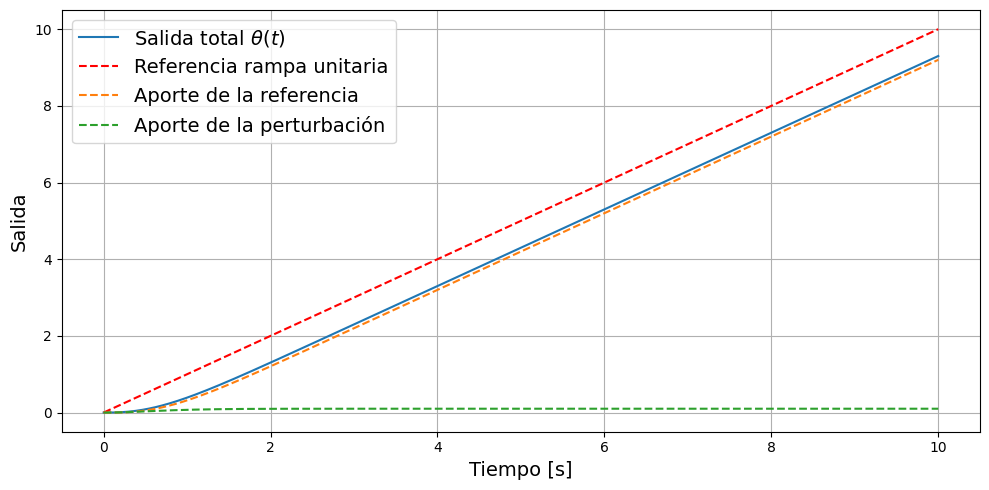

In [23]:
den = [0.003, 0.0515, 0.2, 0.25]

Tv = ctrl.TransferFunction([0.25], den)
Tn = ctrl.TransferFunction([0.25], den)

t = np.linspace(0, 10, 1000)
r = t

t1, y_ref = ctrl.forced_response(Tv, T=t, U=r)

t2, y_pert = ctrl.step_response(0.1 * Tn, T=t)

y_total = y_ref + y_pert

plt.figure(figsize=(10, 5))
plt.plot(t, y_total, label="Salida total $\\theta(t)$")
plt.plot(t, r, "r--", label="Referencia rampa unitaria")

plt.plot(t, y_ref, "--", label="Aporte de la referencia")
plt.plot(t, y_pert, "--", label="Aporte de la perturbación")

plt.xlabel("Tiempo [s]", fontsize=14)
plt.ylabel("Salida", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### e)

Para el caso de la referencia de tipo escalon se deberia introducir el siguiente compensador ...

Para el caso de la referencia de tipo rampa se deberia introducir el siguiente compensador ...

## Parte B)

ts = 2.051694540692734
Mp = 0.0


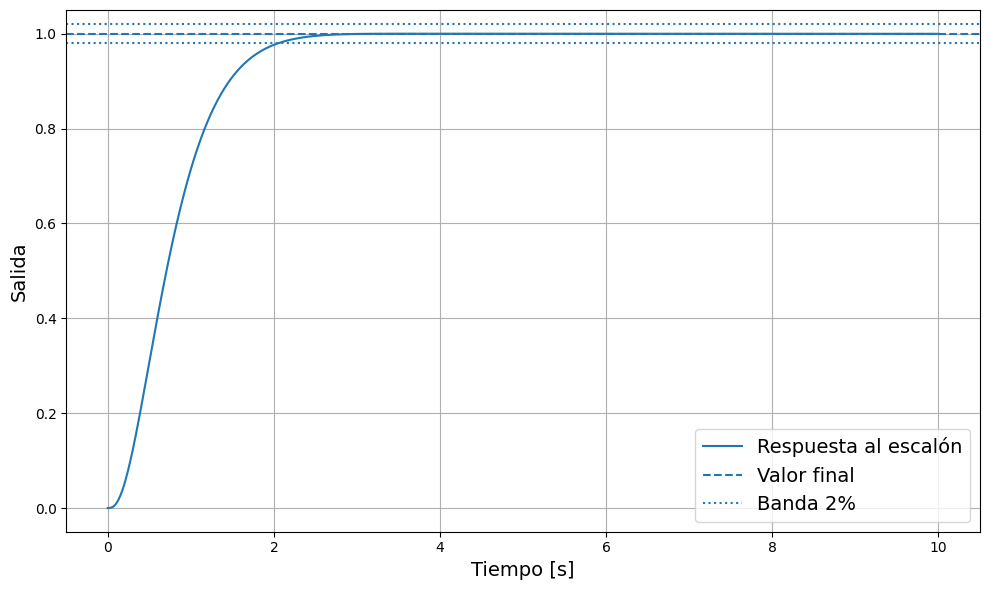

In [24]:
Tv = ctrl.TransferFunction([0.25], [0.003, 0.0515, 0.2, 0])
T = ctrl.feedback(Tv, 1)
info = ctrl.step_info(T, SettlingTimeThreshold=0.02)
print("ts =", info["SettlingTime"])
print("Mp =", info["Overshoot"])

t = np.linspace(0, 10, 1000)
t, y = ctrl.step_response(T, T=t)
plt.figure(figsize=(10,6))
plt.plot(t, y, label='Respuesta al escalón')
plt.axhline(info["SteadyStateValue"], linestyle='--', label='Valor final')
plt.axhline(1.02 * info["SteadyStateValue"], linestyle=':', label='Banda 2%')
plt.axhline(0.98 * info["SteadyStateValue"], linestyle=':')
plt.xlabel("Tiempo [s]", fontsize=14)
plt.ylabel("Salida", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

Precisión

$$\theta(s)=\frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s+ 0.25}V(s) + \frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s+ 0.25}N(s)$$
$$E(s)=R(s) - \theta(s)$$


$$e_{ss}=\lim_{s \to 0}sE(s)$$

$$e_{ss}=\lim_{s \to 0} s[\frac{1}{s} - \frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s+ 0.25}\frac{1}{s} - \frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s+ 0.25}\frac{0.2}{s}]$$

$$e_{ss}= 1 -1 -0.2 = |-0.2|$$

$$e_{ss}= 20\%$$

### b)

No cumple con la precision pedida.
Segun lo que vimos yo pondria un PI.

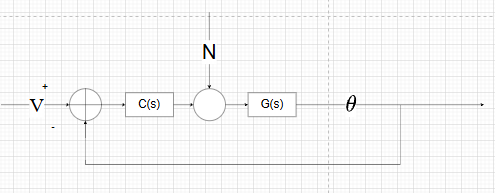

$$E(s)=V(s)-\theta(s)$$

$$\theta = (E(s)C(s) + N(s))G(s)$$

$$\theta = [(V(s)-\theta(s))C(s) + N(s)]G(s)$$

$$(1 + G(s)C(s))\theta = G(s)V(s)C(s) + G(s)N(s)$$

$$\theta = \frac{G(s)C(s)}{1 + G(s)C(s)}V(s) + \frac{G(s)}{1 + G(s)C(s)}N(s)$$


$$\theta(s)=\frac{\theta(s)}{V(s)}V(s) + \frac{\theta(s)}{N(s)}N(s)$$

con $$G(s)=\frac{0.25}{s[0.003s² + 0.0515s + 0.2]}$$

y $$C(s) = K_p + \frac{K_i}{s}$$

con $$G(s)C(s)=\frac{0.25}{s[0.003s² + 0.0515s + 0.2]} C(s)$$


$$\frac{G(s)C(s)}{1 + G(s)C(s)} = \frac{ \frac{0.25}{s[0.003s² + 0.0515s + 0.2]}C(s)}{ 1+ \frac{0.25}{s[0.003s² + 0.0515s + 0.2]}C(s)}$$

$$\frac{G(s)C(s)}{1 + G(s)C(s)} = \frac{0.25(K_p + \frac{K_i}{s})}{0.003s^3 + 0.0515s^2 + 0.2s + 0.25(K_p + \frac{K_i}{s})}$$

$$\frac{G(s)C(s)}{1 + G(s)C(s)} = \frac{0.25(sK_p + K_i)}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i}$$

$$\frac{G(s)}{1 + G(s)C(s)} = \frac{0.25s}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i}$$

$$\theta(s)=\frac{0.25(sK_p + K_i)}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i}V(s) + \frac{0.25s}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i}N(s)$$

Demostramos que $e_{ss}$ da 0.

$$E(s)=R(s) - \theta(s)$$

$$e_{ss}=\lim_{s \to 0}sE(s)$$

$$e_{ss}=\lim_{s \to 0} s[\frac{1}{s} -\frac{\theta(s)}{V(s)}\frac{1}{s} - \frac{\theta(s)}{N(s)}\frac{0.2}{s}]$$

$$\lim_{s \to 0} \frac{\theta(s)}{V(s)} = \lim_{s \to 0}\frac{0.25(sK_p + K_i)}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i} $$

$$\lim_{s \to 0} \frac{\theta}{V(s)} = \frac{0.25K_i}{0.25K_i} = 1$$


$$\lim_{s \to 0} \frac{\theta}{N(s)} = \lim_{s \to 0}\frac{0.25s}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i} $$

$$\lim_{s \to 0} \frac{\theta}{N(s)} = \frac{0}{0.25K_i} $$

si k_i != 0

$$e_{ss}= 1 - 1 - 0 = 0$$


Buscamos: ts <= 7.5 y Mp <= 15

$$M_p \geq e^{-\pi\frac{\zeta}{\sqrt{1-\zeta^2}}}$$

$$\zeta \geq -\frac{\ln(M_p)}{\sqrt{\pi^2+\ln(M_p)^2}}$$


$$\zeta \geq -\frac{\ln(0.15)}{\sqrt{\pi^2+\ln(0.15)^2}}$$

$$\zeta \geq 0.517$$


$$t_s \geq \frac{4}{\zeta\omega_n}$$

$$\omega_n\zeta \geq 0.533$$

Hacemos root locus aproximando a polos dominantes

$S_{1,2}=-\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}$

Tomamos $\zeta=XX, \omega_n=XX$

$S_{1,2}=-XX \pm jXX$

$$ C(s)=K_p\frac{s+z}{s} , z=\frac{K_i}{K_p}, G(s)=\frac{0.25}{s[0.003s² + 0.0515s + 0.2]} $$

$$ C(s)G(s) = \frac{0.25K_p(s+z)}{s^2[0.003s² + 0.0515s + 0.2]}, Polos=0,0,-5.936,-11.23. Zero=-z $$

$$ \angle C(s)G(s) = -180 = -suma angulos de los polos a s_0 + \angle(s_0+z) $$
$$ \frac{0.714}{z-0.7} = tan(suma ...) $$
$$ z = x = \frac{K_i}{K_p} $$
$$ C(s)G(s) = \frac{0.25K_p(s+x)}{s^2[0.003s² + 0.0515s + 0.2]} $$

$$ K_p = \Big|\frac{s^2[0.003s² + 0.0515s + 0.2]}{0.25(s+x)}\Big|_{s=s_0} $$

In [7]:
poles = [0, 0, -5.936, -11.23]
search_zeta_wn(poles)

  zeta     wn        z       Kp       Ki   ts_sim   Mp_sim
-----------------------------------------------------------------
 0.528  3.744   0.0286   2.2397   0.0640    1.683   14.633
 0.551  3.641   0.0448   2.1209   0.0949    1.821   13.843
 0.574  3.538   0.0660   2.0117   0.1329    4.929   13.420
 0.586  3.538   0.0120   1.9641   0.0235    1.793   10.396
 0.609  3.436   0.0409   1.8663   0.0764    2.022   10.474
 0.643  3.333   0.0248   1.7337   0.0431    2.034    8.067
 0.678  3.231   0.0176   1.6136   0.0283    2.085    6.222
 0.712  3.128   0.0188   1.5056   0.0283    2.256    5.008
 0.747  3.026   0.0282   1.4091   0.0397    2.510    4.470
 0.793  2.923   0.0037   1.2877   0.0048    1.353    1.862
 0.827  2.821   0.0304   1.2151   0.0369    3.212    2.947


Chosen s0: -2.317939 + j1.7807548377805966
Pole: 0, Angle (degrees): 142.4668
Pole: 0, Angle (degrees): 142.4668
Pole: -5.936, Angle (degrees): 26.2057
Pole: -11.23, Angle (degrees): 11.2997
Sum of pole angles: -322.4389 degrees
Zero válido en: z = 0.0023
Kp = 1.2864363064001292
K_i = 0.0029975954824075033
ts = 1.3525406629918875
Mp = 1.76412730738722


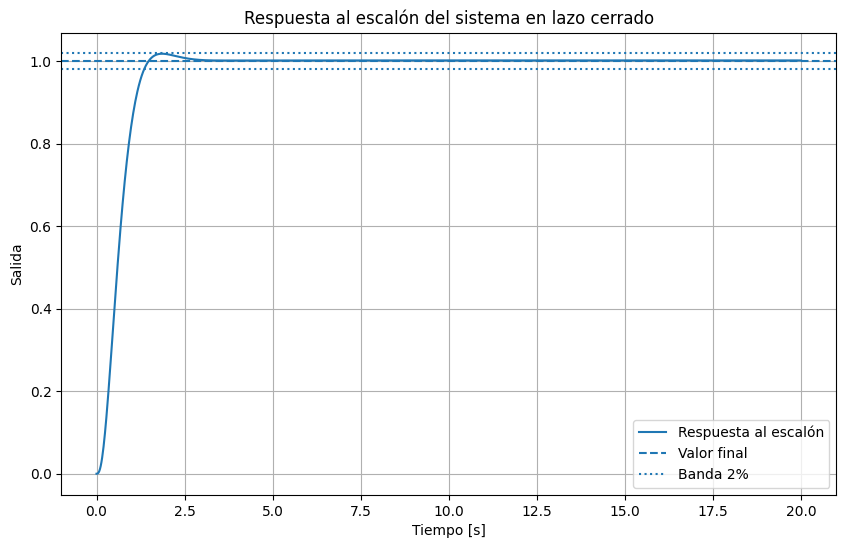

In [8]:
zeta = 0.793
wn = 2.923
poles = [0, 0, -5.936, -11.23]

z, Kp = search_pi(zeta, wn, poles)

### c)

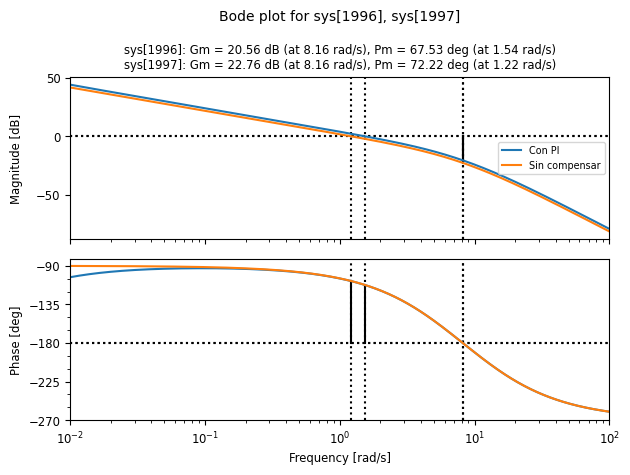

In [26]:
def plot_bode_with_margins(G, title):
    _ = ctrl.bode_plot(G, display_margins=True, omega_limits=(0.01, 100), dB=True, deg=True, label=title)

CG = ctrl.TransferFunction([0.25 * Kp, 0.25 * Kp * z], [0.003, 0.0515, 0.2, 0, 0])
G = ctrl.TransferFunction([0.25], [0.003, 0.0515, 0.2, 0])

cplt = ctrl.bode_plot([CG, G], omega_limits=(0.01, 100), dB=True, deg=True, label=["Con PI", "Sin compensar"], display_margins=True)

plt.show()

### d)

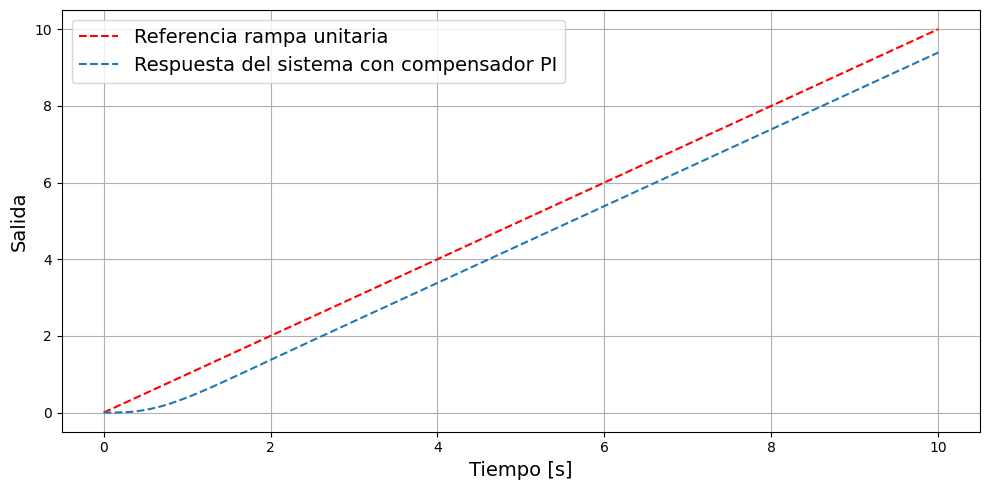

In [27]:
CG = ctrl.TransferFunction([0.25 * Kp, 0.25 * Kp * z], [0.003, 0.0515, 0.2, 0, 0])
T = ctrl.feedback(CG, 1)
t = np.linspace(0, 10, 1000)
r = t
    
t1, y_resp = ctrl.forced_response(T, T=t, U=r)

plt.figure(figsize=(10, 5))
plt.plot(t, r, "r--", label="Referencia rampa unitaria")

plt.plot(t, y_resp, "--", label="Respuesta del sistema con compensador PI")

plt.xlabel("Tiempo [s]", fontsize=14)
plt.ylabel("Salida", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

Si lo hacemos analiticamente:

$$E(s)=R(s) - \theta(s)$$

$$e_{ss}=\lim_{s \to 0}sE(s)$$

$$e_{ss}=\lim_{s \to 0} s[\frac{1}{s^2} -\frac{\theta(s)}{V(s)}\frac{1}{s^2} - \frac{\theta(s)}{N(s)}\frac{0.2}{s}]$$

$$e_{ss}=\lim_{s \to 0} \frac{s}{s^2}[1 -\frac{\theta(s)}{V(s)}] - \frac{\theta(s)}{N(s)}\frac{0.2}{s}$$

$$\lim_{s \to 0} \frac{1}{s}[1 -\frac{\theta(s)}{V(s)}] = \lim_{s \to 0} \frac{1}{s} \frac{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i - 0.25(sK_p + K_i)}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i} $$

$$\lim_{s \to 0} \frac{1}{s}[1 -\frac{\theta(s)}{V(s)}] = \lim_{s \to 0} \frac{0.003s^3 + 0.0515s^2 + 0.2s}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i} $$

$$\lim_{s \to 0} \frac{1}{s}[1 -\frac{\theta(s)}{V(s)}] = \frac{0}{0.25K_i} = 0 $$


$$\lim_{s \to 0} \frac{\theta}{N(s)} = \lim_{s \to 0}\frac{0.25s}{0.003s^4 + 0.0515s^3 + 0.2s^2 + 0.25K_ps + 0.25K_i} $$

$$\lim_{s \to 0} \frac{\theta}{N(s)} = \frac{0}{0.25K_i} $$

si $k_i \neq 0$

$$e_{ss} = 0 $$


### e)

Cumple.